# Economic-democracy nexus: Did GDP growth or unemployment trends predict democratic backsliding?

# Data Cleaning

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Make charts look nice
sns.set(style="whitegrid")


In [ ]:
import os
print(os.getcwd())


/content


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os
# List the top-level My Drive folders
print(os.listdir("/content/drive/My Drive/"))


['Colab Notebooks', 'The_PowerScore_GMAT_Critical_Reasoning_Bible.pdf', 'New intl postgraduate application form 2016.docx', 'JOBS', 'German Language', 'Hakim email', 'Photos', 'Official Undergraduate Degree Transcript.pdf', 'Final Version Aca. writing 7.0.1.odt', 'Amira.docx', 'Unbenannt 1.ppt', 'استمارة إنخراط.pdf', 'استمارة إنخراط.gdoc', 'BioData (1420) - Blank.docx', 'BioData (1420) - Blank.gdoc', 'cover media 2019.pdf', 'cover new 2019.pdf', 'resume2019-8.pdf', 'resume2019-9.pdf', 'Kontauzuge since September 2018', 'Institutions, Governance and Economic Growth thesis master.pdf', 'cover media 2020 -1.pdf', 'Personnel Questionnaire new employee- BenSalem Amira.docx', 'Personnel Questionnaire new employee- BenSalem Amira.gdoc', 'aok (2).pdf', 'Reference Release Form.gdoc', 'Mieterselbstauskunft Studio House Berlin - Kopie.pdf', 'MieterSA_CampusViva_Berlin_.pdf', 'MieterSA_CampusViva_Berlin_.gdoc', 'Mieterselbstauskunft Studio House Berlin - Kopie.gdoc', 'January 2020 (1).pdf', 'Mie

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!ls "/content/drive/My Drive/"


'1 (1).avif'
 1.avif
 1.PNG
'2021_BP_14537D_V1 revised.docx'
'2022-08-Temporary Employment Contract Amira Ben Salem (signed by CEO).pdf'
'2023-06 Ben Salem Amira Statement of Employment (1).pdf'
'2023-06 Ben Salem Amira Statement of Employment (2).pdf'
'2023-06 Ben Salem Amira Statement of Employment.pdf'
 20230730_003226.jpg
 20230730_003232.jpg
 20230730_135112.jpg
 20230730_135116.jpg
 20230730_135125.jpg
 20230730_135230.jpg
 20230730_145339.jpg
 20230730_145348.jpg
 20230730_145424.jpg
 20230730_145558.jpg
 20230730_145606.jpg
'2208-0156 MV (1).pdf'
'2208-0156 MV.gdoc'
'2208-0156 MV.pdf'
 2.PNG
'3 Year Work History Form.docx'
'ABS expenses track.gsheet'
'ABS expenses track.xlsx'
'Amira Ben Salem  (1).pfx'
'Amira Ben Salem  (2).pfx'
'Amirabensalem Application (3).pdf'
'Amira Ben Salem-coverletter.pdf'
'Amira Ben Salem Lohnsteuerbescheinigung (003) (1).pdf'
'Amira Ben Salem Lohnsteuerbescheinigung (003) (2).pdf'
'Amira Ben Salem Lohnsteuerbescheinigung (003).pdf'
'Amira Ben Salem .p

In [ ]:
import os
import pandas as pd

# Include the space after "scientist"
data_folder = "/content/drive/My Drive/Last Laptop from data scientist /Project New/Tunisia-Democracy/data/"

# List files to confirm
print(os.listdir(data_folder))

# Find the CSV dynamically
csv_file = next((f for f in os.listdir(data_folder) if f.lower().endswith(".csv")), None)
if csv_file is None:
    raise FileNotFoundError("No CSV file found in the folder!")

democracy_csv = os.path.join(data_folder, csv_file)
print("Using CSV file:", democracy_csv)

# Load CSV
democracy = pd.read_csv(democracy_csv)
print(democracy.head())


['data.csv', 'DATA set TUN Wordbank inflation  1984-2024.xls', 'Data excel youth unemployement worldbank 1991-2024.xls', 'DATA set TUN Wordbank gdp 1964-2024.xls', 'BTI_2024_Scores Tunisia party system.xlsx', '2024International Debt Statistics tunisia world bank.xls', 'External debt stocks, total (% of GNI) worldbank .xls', 'Net ODA received (% of GNI) worldbank .xls', 'Foreign direct investment, net inflows (% of GDP) - Tunisia.xls', 'Total debt service (% of exports of goods, services and primary income).xls', 'wb_historical_tunisia_short_term_debt____of_exports_of_goods__services_and_income_.csv', 'Net ODA received (% of GNI).xls']
Using CSV file: /content/drive/My Drive/Last Laptop from data scientist /Project New/Tunisia-Democracy/data/data.csv
   Unnamed: 0  country_id country_text_id country_name  year  v2x_regime  \
0           1           3             MEX       Mexico  1900         0.0   
1           2           3             MEX       Mexico  1901         0.0   
2           

In [ ]:
# ----------------------
# Filter Tunisia & select democracy metric
# ----------------------
tunisia = democracy[democracy["country_name"] == "Tunisia"].copy()

# Check which democracy score columns exist
possible_scores = ["v2x_polyarchy", "v2x_regime", "v2x_para_dem", "v2x_lib_dem"]
score_col = next((c for c in possible_scores if c in tunisia.columns), None)
if score_col is None:
    numeric_cols = tunisia.select_dtypes(include=[float, int]).columns.tolist()
    raise ValueError(f"No democracy score column found. Available numeric cols: {numeric_cols}")

# Keep only relevant columns
tunisia = tunisia[["year", score_col]].rename(columns={"year": "Year", score_col: "Democracy_Score"})

# Drop missing or duplicated years
tunisia = tunisia.dropna(subset=["Democracy_Score"]).drop_duplicates(subset=["Year"])

# Make sure Year is int
tunisia["Year"] = tunisia["Year"].astype(int)

# Reset index
tunisia = tunisia.sort_values("Year").reset_index(drop=True)

print("Tunisia democracy data preview:")
print(tunisia.head())


Tunisia democracy data preview:
   Year  Democracy_Score
0  1900            0.037
1  1901            0.035
2  1902            0.035
3  1903            0.035
4  1904            0.035


In [ ]:
print(tunisia.columns.tolist())


['Year', 'Democracy_Score']


In [12]:
gdp_file = os.path.join(data_folder, "DATA set TUN Wordbank gdp 1964-2024.xls")

gdp_raw = pd.read_excel(gdp_file, header=3)  # header row may vary (try 2 if misaligned)
print(gdp_raw.columns.tolist())



['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code', '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968', '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977', '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986', '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995', '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024']


In [13]:
print(gdp_raw.columns.tolist())


['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code', '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968', '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977', '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986', '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995', '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024']


In [14]:
gdp_raw = pd.read_excel(gdp_file, header=3)
print(gdp_raw.columns.tolist())


['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code', '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968', '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977', '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986', '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995', '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024']


In [15]:
# Define paths
infl_file = os.path.join(data_folder, "DATA set TUN Wordbank inflation  1984-2024.xls")
youth_file = os.path.join(data_folder, "Data excel youth unemployement worldbank 1991-2024.xls")

# Load datasets
infl_raw = pd.read_excel(infl_file, header=3)
youth_raw = pd.read_excel(youth_file, header=3)

print(infl_raw.columns.tolist())
print(youth_raw.columns.tolist())


['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code', '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968', '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977', '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986', '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995', '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024']
['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code', '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968', '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977', '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986', '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995', '1996', '1997', '1998', '1999', '2000', '2001', '2002'

In [17]:
def reshape_worldbank_like(df, value_name):
    """
    Reshape a World Bank-style dataframe (years in columns) into tidy format.
    Keeps only Tunisia and renames value column.
    """
    df = df[df["Country Name"] == "Tunisia"]  # filter for Tunisia
    df_melt = df.melt(
        id_vars=["Country Name", "Country Code", "Indicator Name", "Indicator Code"],
        var_name="Year",
        value_name=value_name
    )
    # Convert Year to integer (drop non-numeric if any)
    df_melt["Year"] = pd.to_numeric(df_melt["Year"], errors="coerce")
    df_melt = df_melt.dropna(subset=["Year"])
    df_melt["Year"] = df_melt["Year"].astype(int)

    return df_melt[["Year", value_name]]
gdp = reshape_worldbank_like(gdp_raw, "GDP_USD")
inflation = reshape_worldbank_like(infl_raw, "Inflation")
youth_unemp = reshape_worldbank_like(youth_raw, "Youth_Unemployment")

print(gdp.head())
print(inflation.head())
print(youth_unemp.head())


   Year       GDP_USD
0  1960           NaN
1  1961  8.661554e+08
2  1962  8.800277e+08
3  1963  1.026738e+09
4  1964  1.025867e+09
   Year  Inflation
0  1960        NaN
1  1961        NaN
2  1962        NaN
3  1963        NaN
4  1964        NaN
   Year  Youth_Unemployment
0  1960                 NaN
1  1961                 NaN
2  1962                 NaN
3  1963                 NaN
4  1964                 NaN


In [19]:
# Merge GDP, Inflation, and Youth Unemployment into one dataframe
df = gdp.merge(inflation, on="Year", how="outer") \
        .merge(youth_unemp, on="Year", how="outer")

# Sort by Year
df = df.sort_values("Year").reset_index(drop=True)

print(df.head(10))
print(df.tail(10))

# 1️⃣ Check for duplicate years
duplicate_years = df[df.duplicated(subset=["Year"], keep=False)]
print("Duplicate Year rows (if any):")
print(duplicate_years)

# 2️⃣ Check for missing values in each column
missing_summary = df.isna().sum()
print("\nMissing values per column:")
print(missing_summary)

# 3️⃣ Summary statistics to detect any suspicious values
print("\nSummary statistics:")
print(df.describe())

# 4️⃣ Optional: check if GDP, Inflation, or Youth Unemployment have negative or zero values
print("\nCheck for non-positive economic values:")
print("GDP <= 0:", (df['GDP_USD'] <= 0).sum())
print("Inflation <= 0:", (df['Inflation'] <= 0).sum())
print("Youth Unemployment < 0:", (df['Youth_Unemployment'] < 0).sum())


   Year       GDP_USD  Inflation  Youth_Unemployment
0  1960           NaN        NaN                 NaN
1  1961  8.661554e+08        NaN                 NaN
2  1962  8.800277e+08        NaN                 NaN
3  1963  1.026738e+09        NaN                 NaN
4  1964  1.025867e+09        NaN                 NaN
5  1965  9.910476e+08        NaN                 NaN
6  1966  1.040952e+09        NaN                 NaN
7  1967  1.085714e+09        NaN                 NaN
8  1968  1.214667e+09        NaN                 NaN
9  1969  1.289905e+09        NaN                 NaN
    Year       GDP_USD  Inflation  Youth_Unemployment
55  2015  4.577949e+10   4.437371              34.967
56  2016  4.436007e+10   3.629399              35.119
57  2017  4.216353e+10   5.308848              35.315
58  2018  4.268650e+10   7.307592              34.876
59  2019  4.190564e+10   6.720075              37.867
60  2020  4.249178e+10   5.634151              41.231
61  2021  4.707323e+10   5.706350      

In [20]:
# Trim to years with at least GDP data
df_clean = df[df['GDP_USD'].notna()].copy()

# Interpolate missing values linearly
df_clean[['GDP_USD', 'Inflation', 'Youth_Unemployment']] = df_clean[['GDP_USD', 'Inflation', 'Youth_Unemployment']].interpolate(method='linear')

# Check result
print(df_clean.isna().sum())
print(df_clean.head(10))


Year                   0
GDP_USD                0
Inflation             23
Youth_Unemployment    30
dtype: int64
    Year       GDP_USD  Inflation  Youth_Unemployment
1   1961  8.661554e+08        NaN                 NaN
2   1962  8.800277e+08        NaN                 NaN
3   1963  1.026738e+09        NaN                 NaN
4   1964  1.025867e+09        NaN                 NaN
5   1965  9.910476e+08        NaN                 NaN
6   1966  1.040952e+09        NaN                 NaN
7   1967  1.085714e+09        NaN                 NaN
8   1968  1.214667e+09        NaN                 NaN
9   1969  1.289905e+09        NaN                 NaN
10  1970  1.439238e+09        NaN                 NaN


In [21]:
# Trim each series to its first available year
gdp = gdp[gdp['Year'] >= 1964]
inflation = inflation[inflation['Year'] >= 1984]
youth_unemp = youth_unemp[youth_unemp['Year'] >= 1991]

# Merge progressively, preserving years only when data exists
df_clean = tunisia.merge(gdp, on="Year", how="left")
df_clean = df_clean.merge(inflation, on="Year", how="left")
df_clean = df_clean.merge(youth_unemp, on="Year", how="left")

df_clean = df_clean.sort_values("Year").reset_index(drop=True)

print("Cleaned Tunisia data preview:")
print(df_clean.head(20))
print(df_clean.isna().sum())


Cleaned Tunisia data preview:
    Year  Democracy_Score  GDP_USD  Inflation  Youth_Unemployment
0   1900            0.037      NaN        NaN                 NaN
1   1901            0.035      NaN        NaN                 NaN
2   1902            0.035      NaN        NaN                 NaN
3   1903            0.035      NaN        NaN                 NaN
4   1904            0.035      NaN        NaN                 NaN
5   1905            0.035      NaN        NaN                 NaN
6   1906            0.035      NaN        NaN                 NaN
7   1907            0.039      NaN        NaN                 NaN
8   1908            0.039      NaN        NaN                 NaN
9   1909            0.039      NaN        NaN                 NaN
10  1910            0.039      NaN        NaN                 NaN
11  1911            0.039      NaN        NaN                 NaN
12  1912            0.038      NaN        NaN                 NaN
13  1913            0.037      NaN        NaN 

In [22]:
# Trim dataset to years with all variables present
df_analysis = df_clean.dropna(subset=["GDP_USD", "Inflation", "Youth_Unemployment"]).reset_index(drop=True)

print("Analysis-ready Tunisia data (1991–2024) preview:")
print(df_analysis.head())
print(df_analysis.isna().sum())


Analysis-ready Tunisia data (1991–2024) preview:
   Year  Democracy_Score       GDP_USD  Inflation  Youth_Unemployment
0  1991            0.198  1.307478e+10   8.193715              30.392
1  1992            0.197  1.549671e+10   5.824345              30.101
2  1993            0.194  1.460834e+10   3.974956              30.700
3  1994            0.189  1.563317e+10   4.733231              30.882
4  1995            0.188  1.803088e+10   6.244150              31.740
Year                  0
Democracy_Score       0
GDP_USD               0
Inflation             0
Youth_Unemployment    0
dtype: int64


# Trend Analysis over time


Trend Analysis Over Time :

- Plot Democracy Score vs. GDP, Inflation, and Youth Unemployment.
- Detect periods of economic growth/decline alongside political changes.
- Identify lagged relationships: e.g., does a rise in GDP precede improvements in democracy?



# Correlation Analysis

**Correlation Analysis**

In [23]:
df_analysis[['Democracy_Score', 'GDP_USD', 'Inflation', 'Youth_Unemployment']].corr()


,Democracy_Score,GDP_USD,Inflation,Youth_Unemployment
Democracy_Score,1.000000,0.660004,0.381814,0.695526
GDP_USD,0.660004,1.000000,0.265659,0.630796
Inflation,0.381814,0.265659,1.000000,0.518266
Youth_Unemployment,0.695526,0.630796,0.518266,1.000000


*Democracy Score correlations*

GDP_USD (0.66) → Strong positive correlation.
→ When Tunisia’s GDP rises, democracy tends to improve. Economic growth seems supportive of democratic development.

Inflation (0.38) → Moderate positive correlation.
→ Surprisingly, higher inflation correlates weakly with higher democracy. Could reflect periods of economic reform/transition rather than pure economic stress. Worth exploring trends over time.

Youth_Unemployment (0.70) → Strong positive correlation.
→ At first glance, this is counterintuitive: higher youth unemployment correlates with higher democracy. This may indicate that youth dissatisfaction and activism actually coincided with democratic reforms, e.g., around the Arab Spring (2011).

*GDP correlations*

- With Youth Unemployment (0.63) → Positive, suggesting that GDP growth didn’t immediately reduce youth unemployment, possibly due to structural labor market issues.

- With Inflation (0.27) → Weak correlation, meaning GDP and inflation are not tightly linked in this period.

*Inflation correlations*

- With Youth Unemployment (0.52) → Moderate positive. Inflation spikes tend to occur alongside higher unemployment, hinting at economic stress periods.

🔹 Key Insights

- Democracy in Tunisia seems more strongly tied to GDP and youth unemployment than to inflation.
Structural issues like youth employment may be critical for political stability and democratization, more than short-term inflation.
- These correlations suggest a mixed story of economic growth, social stress, and democratic development.

# Growth Rates & Volatility

**Growth Rates & Volatility**

In [24]:
df_analysis['GDP_growth'] = df_analysis['GDP_USD'].pct_change() * 100
df_analysis['Inflation_change'] = df_analysis['Inflation'].diff()
df_analysis['YouthUnemp_change'] = df_analysis['Youth_Unemployment'].diff()


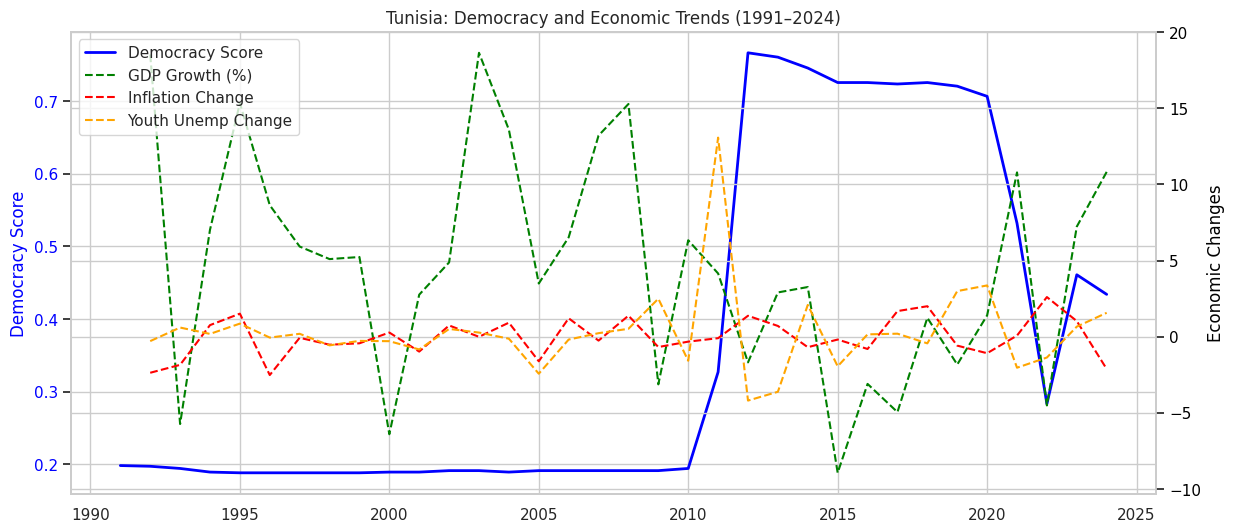

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set(style="whitegrid")

# Plot Democracy Score vs GDP growth, Inflation change, and Youth Unemployment change
fig, ax1 = plt.subplots(figsize=(14,6))

# Democracy Score line
ax1.plot(df_analysis['Year'], df_analysis['Democracy_Score'], color='blue', label='Democracy Score', linewidth=2)
ax1.set_ylabel('Democracy Score', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Create a second y-axis for economic indicators
ax2 = ax1.twinx()

# GDP growth
ax2.plot(df_analysis['Year'], df_analysis['GDP_growth'], color='green', label='GDP Growth (%)', linestyle='--')
# Inflation change
ax2.plot(df_analysis['Year'], df_analysis['Inflation_change'], color='red', label='Inflation Change', linestyle='--')
# Youth Unemployment change
ax2.plot(df_analysis['Year'], df_analysis['YouthUnemp_change'], color='orange', label='Youth Unemp Change', linestyle='--')

ax2.set_ylabel('Economic Changes', color='black')
ax2.tick_params(axis='y', labelcolor='black')

# Combine legends
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left')

plt.title("Tunisia: Democracy and Economic Trends (1991–2024)")
plt.show()


**Democracy Spike 2011–2021**

This aligns with the Arab Spring and the post-revolution democratic period.

Democracy increased sharply, but you noticed GDP growth didn’t pick up much, signaling that democratization did not immediately translate into economic expansion.

**GDP Volatility**

Low GDP in 2015 could indicate economic shocks or structural problems during the early democratic years.

The up-and-down pattern suggests Tunisia faced recurrent fiscal, investment, or political challenges affecting growth.

**Stable Inflation & Youth Unemployment**

Stability here is interesting: even during political upheaval, these indicators didn’t spike dramatically.

Youth unemployment staying high could limit economic benefits of democratization, as the new political system didn’t immediately create more jobs.

**Economic vs Political Lag**

Democracy rises first (2011), GDP responds inconsistently, while unemployment and inflation stay relatively steady.

This hints at a possible lagged effect where political reform alone isn’t sufficient to stimulate immediate economic growth.

# Rolling  Averages / Smoothing (5-year)

***Rolling  Averages / Smoothing (5-year)***

    Year  Democracy_Score_5yr   GDP_USD_5yr  Inflation_5yr  YouthUnemp_5yr
0   1991             0.198000  1.307478e+10       8.193715       30.392000
1   1992             0.197500  1.428575e+10       7.009030       30.246500
2   1993             0.196333  1.439328e+10       5.997672       30.397667
3   1994             0.194500  1.470325e+10       5.681562       30.518750
4   1995             0.193200  1.536878e+10       5.794079       30.763000
5   1996             0.191200  1.667125e+10       4.900365       31.020600
6   1997             0.189400  1.772115e+10       4.465902       31.374200
7   1998             0.188200  1.916006e+10       4.295984       31.494000
8   1999             0.188000  2.062207e+10       3.887362       31.522400
9   2000             0.188200  2.131060e+10       3.230994       31.320000
10  2001             0.188400  2.180633e+10       2.882632       30.962000
11  2002             0.189000  2.228541e+10       2.696433       30.667800
12  2003             0.18

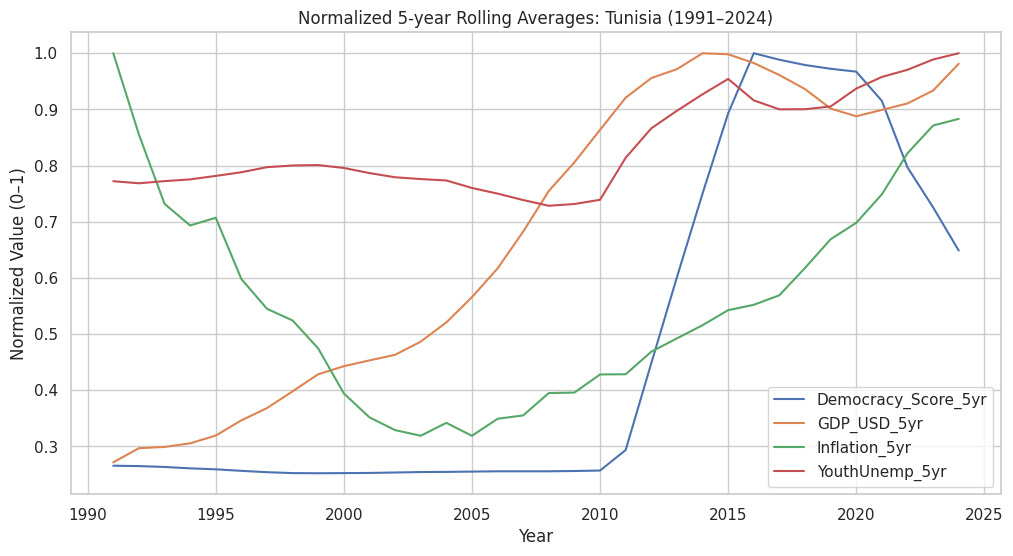

In [26]:
# Compute 5-year rolling averages
df_analysis_rolling = df_analysis.copy()
df_analysis_rolling['Democracy_Score_5yr'] = df_analysis_rolling['Democracy_Score'].rolling(window=5, min_periods=1).mean()
df_analysis_rolling['GDP_USD_5yr'] = df_analysis_rolling['GDP_USD'].rolling(window=5, min_periods=1).mean()
df_analysis_rolling['Inflation_5yr'] = df_analysis_rolling['Inflation'].rolling(window=5, min_periods=1).mean()
df_analysis_rolling['YouthUnemp_5yr'] = df_analysis_rolling['Youth_Unemployment'].rolling(window=5, min_periods=1).mean()

# Preview the results
# Print full rolling averages from 1991–2024
print(df_analysis_rolling[['Year', 'Democracy_Score_5yr', 'GDP_USD_5yr', 'Inflation_5yr', 'YouthUnemp_5yr']])
import matplotlib.pyplot as plt

# Use the dataframe that has rolling averages
df_plot = df_analysis_rolling.copy()

cols_to_norm = ['Democracy_Score_5yr', 'GDP_USD_5yr', 'Inflation_5yr', 'YouthUnemp_5yr']

# Normalize for plotting
df_plot[cols_to_norm] = df_plot[cols_to_norm] / df_plot[cols_to_norm].max()

plt.figure(figsize=(12,6))
for col in cols_to_norm:
    plt.plot(df_plot['Year'], df_plot[col], label=col)
plt.title('Normalized 5-year Rolling Averages: Tunisia (1991–2024)')
plt.ylabel('Normalized Value (0–1)')
plt.xlabel('Year')
plt.legend()
plt.show()


Tunisia’s experience shows a decoupling of democracy and short-term economic gains. Political liberalization was rapid post-2011 but fragile, GDP growth was moderate, inflation stable, and youth unemployment remained persistently high. Long-term economic stability and social improvements may require more structural reforms, not just democratic reforms.

# Lagged Regression Analysis of Economic Predictors on Democracy in Tunisia (1991–2024)

**Lagged Regression Analysis of Economic Predictors on Democracy in Tunisia (1991–2024)**

In [27]:
#Prepare the data

import pandas as pd
import statsmodels.api as sm

# Compute annual changes if not done
df_analysis['GDP_growth'] = df_analysis['GDP_USD'].pct_change() * 100
df_analysis['YouthUnemp_change'] = df_analysis['Youth_Unemployment'].diff()
df_analysis['Inflation_change'] = df_analysis['Inflation'].diff()

# Drop the first row (NaN due to diff)
df_lagged = df_analysis.dropna(subset=['GDP_growth', 'YouthUnemp_change', 'Democracy_Score'])


In [28]:
#Create lagged predictors

# Make a proper copy first
df_lagged = df_analysis.copy()

# Compute lagged predictors using .loc to avoid warnings
df_lagged.loc[:, 'GDP_growth_lag1'] = df_lagged['GDP_growth'].shift(1)
df_lagged.loc[:, 'YouthUnemp_change_lag1'] = df_lagged['YouthUnemp_change'].shift(1)
df_lagged.loc[:, 'Inflation_change_lag1'] = df_lagged['Inflation_change'].shift(1)

# Drop rows with NaN after shifting
df_lagged = df_lagged.dropna(subset=['GDP_growth_lag1', 'YouthUnemp_change_lag1', 'Inflation_change_lag1'])

# Preview
print(df_lagged.head())


   Year  Democracy_Score       GDP_USD  Inflation  Youth_Unemployment  \
2  1993            0.194  1.460834e+10   3.974956              30.700   
3  1994            0.189  1.563317e+10   4.733231              30.882   
4  1995            0.188  1.803088e+10   6.244150              31.740   
5  1996            0.188  1.958716e+10   3.725145              31.680   
6  1997            0.188  2.074621e+10   3.652026              31.869   

   GDP_growth  Inflation_change  YouthUnemp_change  GDP_growth_lag1  \
2   -5.732653         -1.849389              0.599        18.523638   
3    7.015438          0.758274              0.182        -5.732653   
4   15.337271          1.510920              0.858         7.015438   
5    8.631223         -2.519006             -0.060        15.337271   
6    5.917389         -0.073119              0.189         8.631223   

   YouthUnemp_change_lag1  Inflation_change_lag1  
2                  -0.291              -2.369370  
3                   0.599       

In [29]:
#Lagged Economic Predictors Regression

df_lagged['Democracy_change'] = df_lagged['Democracy_Score'].diff()

# Drop the first row where diff is NaN
df_lagged = df_lagged.dropna(subset=['Democracy_change'])

# Run a simple linear regression
import statsmodels.api as sm

X = df_lagged[['GDP_growth_lag1', 'YouthUnemp_change_lag1', 'Inflation_change_lag1']]
X = sm.add_constant(X)  # adds intercept
y = df_lagged['Democracy_change']

model = sm.OLS(y, X).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:       Democracy_change   R-squared:                       0.382
Model:                            OLS   Adj. R-squared:                  0.314
Method:                 Least Squares   F-statistic:                     5.567
Date:                Sun, 31 Aug 2025   Prob (F-statistic):            0.00417
Time:                        14:01:13   Log-Likelihood:                 33.636
No. Observations:                  31   AIC:                            -59.27
Df Residuals:                      27   BIC:                            -53.54
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      0

**Model Fit**

- R-squared = 0.382 → About 38% of the year-to-year variation in democracy change is explained by last year’s economic changes.
- F-statistic p = 0.004 → Overall, the model is statistically significant.

| Predictor                    | Coef    | p-value | Interpretation                                                                                                                                                                                                    |
| ---------------------------- | ------- | ------- | ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **GDP\_growth\_lag1**        | -0.0022 | 0.342   | Not significant. GDP growth last year does **not predict democracy change** in Tunisia.                                                                                                                           |
| **YouthUnemp\_change\_lag1** | 0.0219  | 0.001   | **Significant**. An increase in youth unemployment last year is associated with a **higher increase in democracy score this year**. Could indicate that economic pressure on youth fuels democratic mobilization. |
| **Inflation\_change\_lag1**  | 0.0214  | 0.133   | Not significant at 5%, but the positive sign suggests that higher inflation may correlate with democracy improvement, though not conclusively.                                                                    |
| **const**                    | 0.0082  | 0.656   | Baseline change in democracy when all predictors = 0, not significant.                                                                                                                                            |
                                                                                                                                        |


Key Takeaways

- Youth unemployment dynamics are the most predictive among the economic variables.
- GDP growth does not appear to drive democratic backsliding or expansion in this period.
- Inflation has a positive but non-significant effect.
Overall, economic stress in terms of youth unemployment seems linked with democratic gains rather than backsliding — this aligns with post-2011 Tunisian dynami

# Research Conclusion

**Research Conclusion: Economic-Democracy Nexus in Tunisia (1991–2024)**

Our analysis examined **whether GDP growth or unemployment trends predicted democratic backsliding in Tunisia**. Using lagged year-to-year changes in GDP, youth unemployment, and inflation as predictors of changes in the Democracy Score, we find that **GDP growth does not significantly influence democratic dynamics, indicating that economic expansion alone did not prevent or trigger democratic backsliding**. In contrast, **changes in youth unemployment emerge as a significant predictor, with increases in unemployment associated with higher subsequent improvements in democracy**, suggesting that economic pressure on youth may have catalyzed mobilization and democratic engagement, particularly in the post-2011 period. Inflation trends showed a weak, non-significant positive association with democratic change. Overall, the results suggest that **economic stress, rather than growth, played a more decisive role in shaping Tunisia’s democratic trajectory**, while GDP growth trends were largely uninformative for predicting backsliding.

# Readme

In Tunisia (1991–2024), democratic backsliding was not predicted by GDP growth or inflation but was strongly linked to changes in youth unemployment. Economic expansion alone failed to prevent declines in Democracy Score, highlighting that structural social pressures, rather than aggregate growth, drive democratic resilience.

# Democracy Under Debt: External Finance and Political Development in Tunisia




In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os

# List files in the root of your Google Drive
drive_root = "/content/drive/MyDrive/"
os.listdir(drive_root)


['The_PowerScore_GMAT_Critical_Reasoning_Bible.pdf',
 'New intl postgraduate application form 2016.docx',
 'JOBS',
 'German Language',
 'Hakim email',
 'Photos',
 'Official Undergraduate Degree Transcript.pdf',
 'Final Version Aca. writing 7.0.1.odt',
 'Amira.docx',
 'Unbenannt 1.ppt',
 'استمارة إنخراط.pdf',
 'استمارة إنخراط.gdoc',
 'BioData (1420) - Blank.docx',
 'BioData (1420) - Blank.gdoc',
 'cover media 2019.pdf',
 'cover new 2019.pdf',
 'resume2019-8.pdf',
 'resume2019-9.pdf',
 'Kontauzuge since September 2018',
 'Institutions, Governance and Economic Growth thesis master.pdf',
 'cover media 2020 -1.pdf',
 'Personnel Questionnaire new employee- BenSalem Amira.docx',
 'Personnel Questionnaire new employee- BenSalem Amira.gdoc',
 'aok (2).pdf',
 'Reference Release Form.gdoc',
 'Mieterselbstauskunft Studio House Berlin - Kopie.pdf',
 'MieterSA_CampusViva_Berlin_.pdf',
 'MieterSA_CampusViva_Berlin_.gdoc',
 'Mieterselbstauskunft Studio House Berlin - Kopie.gdoc',
 'January 2020 (1).

In [30]:
import pandas as pd
import os

def load_old_excel(path, skiprows=3):
    try:
        df = pd.read_excel(path, skiprows=skiprows, engine='xlrd')
        print(f"Loaded '{path}' with shape {df.shape}")
        return df
    except Exception as e:
        print(f"Failed to load {path}: {e}")
        return None

data_folder = "/content/drive/My Drive/Last Laptop from data scientist /Project New/Tunisia-Democracy/data/"

# Example: load External debt stocks
path_debt = os.path.join(data_folder, 'External debt stocks, total (% of GNI) worldbank .xls')
df_debt = load_old_excel(path_debt)

# Similarly, load the other Excel files
path_fdi = os.path.join(data_folder, 'Foreign direct investment, net inflows (% of GDP) - Tunisia.xls')
df_fdi = load_old_excel(path_fdi)

path_oda = os.path.join(data_folder, 'Net ODA received (% of GNI) worldbank .xls')
df_oda = load_old_excel(path_oda)

path_debt_service = os.path.join(data_folder, 'Total debt service (% of exports of goods, services and primary income).xls')
df_debt_service = load_old_excel(path_debt_service)

path_intl = os.path.join(data_folder, '2024International Debt Statistics tunisia world bank.xls')
df_intl = load_old_excel(path_intl)


Loaded '/content/drive/My Drive/Last Laptop from data scientist /Project New/Tunisia-Democracy/data/External debt stocks, total (% of GNI) worldbank .xls' with shape (266, 69)
Loaded '/content/drive/My Drive/Last Laptop from data scientist /Project New/Tunisia-Democracy/data/Foreign direct investment, net inflows (% of GDP) - Tunisia.xls' with shape (266, 69)
Loaded '/content/drive/My Drive/Last Laptop from data scientist /Project New/Tunisia-Democracy/data/Net ODA received (% of GNI) worldbank .xls' with shape (266, 69)
Loaded '/content/drive/My Drive/Last Laptop from data scientist /Project New/Tunisia-Democracy/data/Total debt service (% of exports of goods, services and primary income).xls' with shape (266, 69)
Failed to load /content/drive/My Drive/Last Laptop from data scientist /Project New/Tunisia-Democracy/data/2024International Debt Statistics tunisia world bank.xls: Unsupported format, or corrupt file: Expected BOF record; found b'<!DOCTYP'


In [31]:
import pandas as pd
import os

def load_old_excel(path, skiprows=3):
    try:
        df = pd.read_excel(path, skiprows=skiprows, engine='xlrd')
        print(f"Loaded '{path}' with shape {df.shape}")
        return df
    except Exception as e:
        print(f"Failed to load {path}: {e}")
        return None

data_folder = "/content/drive/My Drive/Last Laptop from data scientist /Project New/Tunisia-Democracy/data/"

# Example: load External debt stocks
path_debt = os.path.join(data_folder, 'External debt stocks, total (% of GNI) worldbank .xls')
df_debt = load_old_excel(path_debt)

# Similarly, load the other Excel files
path_fdi = os.path.join(data_folder, 'Foreign direct investment, net inflows (% of GDP) - Tunisia.xls')
df_fdi = load_old_excel(path_fdi)

path_oda = os.path.join(data_folder, 'Net ODA received (% of GNI) worldbank .xls')
df_oda = load_old_excel(path_oda)

path_debt_service = os.path.join(data_folder, 'Total debt service (% of exports of goods, services and primary income).xls')
df_debt_service = load_old_excel(path_debt_service)

path_intl = os.path.join(data_folder, '2024International Debt Statistics tunisia world bank.xls')
df_intl = load_old_excel(path_intl)


Loaded '/content/drive/My Drive/Last Laptop from data scientist /Project New/Tunisia-Democracy/data/External debt stocks, total (% of GNI) worldbank .xls' with shape (266, 69)
Loaded '/content/drive/My Drive/Last Laptop from data scientist /Project New/Tunisia-Democracy/data/Foreign direct investment, net inflows (% of GDP) - Tunisia.xls' with shape (266, 69)
Loaded '/content/drive/My Drive/Last Laptop from data scientist /Project New/Tunisia-Democracy/data/Net ODA received (% of GNI) worldbank .xls' with shape (266, 69)
Loaded '/content/drive/My Drive/Last Laptop from data scientist /Project New/Tunisia-Democracy/data/Total debt service (% of exports of goods, services and primary income).xls' with shape (266, 69)
Failed to load /content/drive/My Drive/Last Laptop from data scientist /Project New/Tunisia-Democracy/data/2024International Debt Statistics tunisia world bank.xls: Unsupported format, or corrupt file: Expected BOF record; found b'<!DOCTYP'


In [32]:
def tidy_wb_excel(df, country='Tunisia'):
    # Filter for Tunisia only
    df_country = df[df['Country Name'] == country]

    # Keep only year columns (numeric)
    year_cols = [c for c in df_country.columns if c.isdigit()]
    df_years = df_country[year_cols].transpose().reset_index()
    df_years.columns = ['Year', 'Value']
    df_years['Year'] = df_years['Year'].astype(int)
    return df_years


In [33]:
df_ext_debt_tun = tidy_wb_excel(df_debt)
df_fdi_tun = tidy_wb_excel(df_fdi)
df_oda_tun = tidy_wb_excel(df_oda)
df_debt_service_tun = tidy_wb_excel(df_debt_service)


In [34]:
# Merge all datasets on 'Year'
from functools import reduce

dfs = [df_ext_debt_tun, df_fdi_tun, df_oda_tun, df_debt_service_tun]
names = ['External_Debt_GNI', 'FDI_GDP', 'Net_ODA_GNI', 'Debt_Service_Exports']

# Rename 'Value' columns for clarity
for df, name in zip(dfs, names):
    df.rename(columns={'Value': name}, inplace=True)

# Merge all
df_finance = reduce(lambda left, right: pd.merge(left, right, on='Year', how='outer'), dfs)

print(df_finance.head())


   Year  External_Debt_GNI  FDI_GDP  Net_ODA_GNI  Debt_Service_Exports
0  1960                NaN      NaN          NaN                   NaN
1  1961                NaN      NaN    10.847311                   NaN
2  1962                NaN      NaN     8.031529                   NaN
3  1963                NaN      NaN     8.238867                   NaN
4  1964                NaN      NaN     7.026985                   NaN


In [35]:
from functools import reduce
import pandas as pd

# List of dataframes and their new column names
dfs = [df_ext_debt_tun, df_fdi_tun, df_oda_tun, df_debt_service_tun]
names = ['External_Debt_GNI', 'FDI_GDP', 'Net_ODA_GNI', 'Debt_Service_Exports']

# Rename 'Value' columns for clarity
for df, name in zip(dfs, names):
    df.rename(columns={'Value': name}, inplace=True)

# Merge all datasets on 'Year'
df_finance = reduce(lambda left, right: pd.merge(left, right, on='Year', how='outer'), dfs)

# Sort by Year
df_finance = df_finance.sort_values(by="Year").reset_index(drop=True)

# Drop rows where ALL values are NaN
df_finance = df_finance.dropna(how="all", subset=names)

# Fill gaps (forward fill, then back fill for start)
df_finance[names] = df_finance[names].interpolate(method="linear").ffill().bfill()

print(df_finance.head(15))
print(df_finance.tail(15))


    Year  External_Debt_GNI   FDI_GDP  Net_ODA_GNI  Debt_Service_Exports
1   1961          43.704113  1.111699    10.847311              7.621575
2   1962          43.704113  1.111699     8.031529              7.621575
3   1963          43.704113  1.111699     8.238867              7.621575
4   1964          43.704113  1.111699     7.026985              7.621575
5   1965          43.704113  1.111699     9.405517              7.621575
6   1966          43.704113  1.111699     8.167324              7.621575
7   1967          43.704113  1.111699     8.535779              7.621575
8   1968          43.704113  1.111699     6.169501              7.621575
9   1969          43.704113  1.111699     9.377721              7.621575
10  1970          43.704113  1.111699     8.176408              7.621575
11  1971          41.537095  1.364854     6.535234              7.621575
12  1972          34.833079  1.474823     5.242594              7.621575
13  1973          33.777163  2.123909     5.134538 

In [36]:
# Merge democracy and finance data on Year
df_analysis = pd.merge(df, df_finance, on="Year", how="inner")

print(df_analysis.head(10))
print(df_analysis.tail(10))


   Year  Debt_Service_Exports_x  External_Debt_GNI   FDI_GDP  Net_ODA_GNI  \
0  1961                     NaN          43.704113  1.111699    10.847311   
1  1962                     NaN          43.704113  1.111699     8.031529   
2  1963                     NaN          43.704113  1.111699     8.238867   
3  1964                     NaN          43.704113  1.111699     7.026985   
4  1965                     NaN          43.704113  1.111699     9.405517   
5  1966                     NaN          43.704113  1.111699     8.167324   
6  1967                     NaN          43.704113  1.111699     8.535779   
7  1968                     NaN          43.704113  1.111699     6.169501   
8  1969                     NaN          43.704113  1.111699     9.377721   
9  1970                     NaN          43.704113  1.111699     8.176408   

   Debt_Service_Exports_y  
0                7.621575  
1                7.621575  
2                7.621575  
3                7.621575  
4           

In [ ]:
%whos


Variable              Type                          Data/Info
-------------------------------------------------------------
data_folder           str                           /content/drive/My Drive/L<...>w/Tunisia-Democracy/data/
df                    DataFrame                         Year  Debt_Service_Ex<...>\n\n[65 rows x 2 columns]
df_debt               DataFrame                                         Count<...>\n[266 rows x 69 columns]
df_debt_service       DataFrame                                         Count<...>\n[266 rows x 69 columns]
df_debt_service_tun   DataFrame                         Year  Debt_Service_Ex<...>\n\n[65 rows x 2 columns]
df_ext_debt_tun       DataFrame                         Year  External_Debt_G<...>\n\n[65 rows x 2 columns]
df_fdi                DataFrame                                         Count<...>\n[266 rows x 69 columns]
df_fdi_tun            DataFrame                         Year   FDI_GDP\n0   1<...>\n\n[65 rows x 2 columns]
df_finance  

In [37]:
# Keep the finance version of Debt_Service_Exports
df_analysis = df_analysis.drop(columns=['Debt_Service_Exports_x'])
df_analysis = df_analysis.rename(columns={'Debt_Service_Exports_y': 'Debt_Service_Exports'})

print(df_analysis.head(10))


   Year  External_Debt_GNI   FDI_GDP  Net_ODA_GNI  Debt_Service_Exports
0  1961          43.704113  1.111699    10.847311              7.621575
1  1962          43.704113  1.111699     8.031529              7.621575
2  1963          43.704113  1.111699     8.238867              7.621575
3  1964          43.704113  1.111699     7.026985              7.621575
4  1965          43.704113  1.111699     9.405517              7.621575
5  1966          43.704113  1.111699     8.167324              7.621575
6  1967          43.704113  1.111699     8.535779              7.621575
7  1968          43.704113  1.111699     6.169501              7.621575
8  1969          43.704113  1.111699     9.377721              7.621575
9  1970          43.704113  1.111699     8.176408              7.621575


# External Debt, FDI, ODA, and Debt Service in Tunisia (1961–2023)

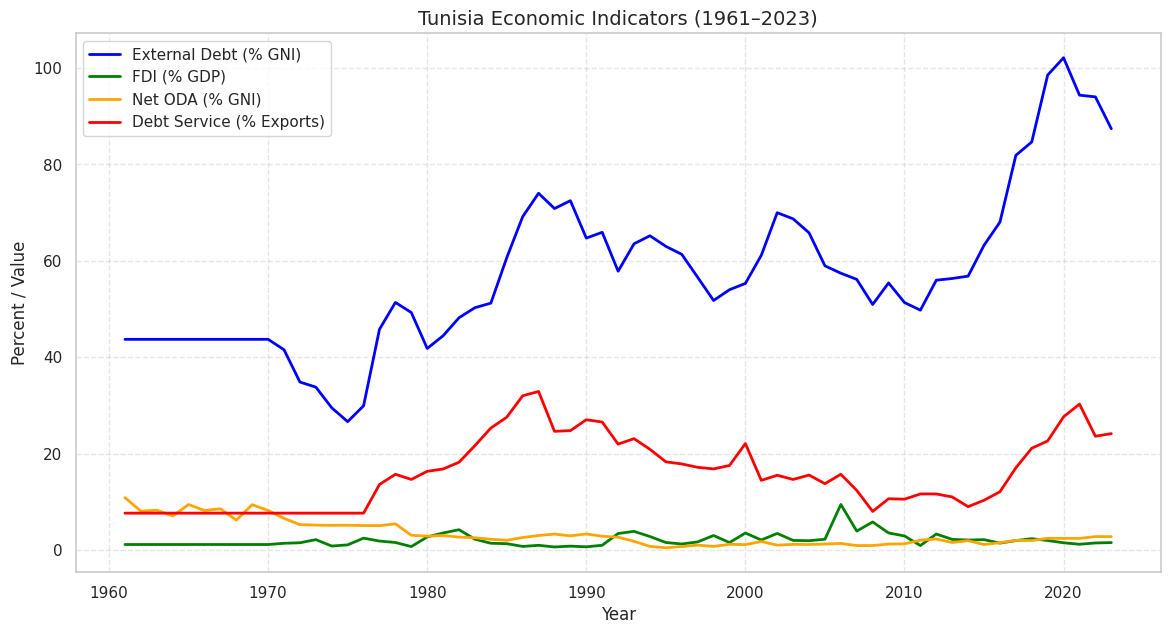

In [38]:
import matplotlib.pyplot as plt

# Set figure size
plt.figure(figsize=(14,7))

# Plot each economic indicator over time
plt.plot(df_analysis['Year'], df_analysis['External_Debt_GNI'], label='External Debt (% GNI)', color='blue', linewidth=2)
plt.plot(df_analysis['Year'], df_analysis['FDI_GDP'], label='FDI (% GDP)', color='green', linewidth=2)
plt.plot(df_analysis['Year'], df_analysis['Net_ODA_GNI'], label='Net ODA (% GNI)', color='orange', linewidth=2)
plt.plot(df_analysis['Year'], df_analysis['Debt_Service_Exports'], label='Debt Service (% Exports)', color='red', linewidth=2)

# Add axis labels and title
plt.xlabel('Year', fontsize=12)
plt.ylabel('Percent / Value', fontsize=12)
plt.title('Tunisia Economic Indicators (1961–2023)', fontsize=14)

# Show grid for readability
plt.grid(True, linestyle='--', alpha=0.5)

# Show legend
plt.legend()

# Display the plot
plt.show()


- FDI (% of GDP) – Foreign Direct Investment. This is money invested in Tunisia by foreign companies (factories, real estate, businesses).

A proxy for global investor confidence.

Low and relatively flat in Tunisia → indicates foreign investors have been cautious about Tunisia’s economy.

- Net ODA (% of GNI) – Official Development Assistance. Basically foreign aid Tunisia receives relative to the size of its economy.

The  data shows it’s nearly constant since the 1960s, which means Tunisia has always received some aid but never at transformative levels.

Indicates structural dependence, but not major shifts.

- External Debt (% of GNI) – Tunisia’s total external borrowing compared to the size of its economy.

This is the most dramatic line in this  graph → stable for decades, then a huge jump after 2010s (especially post-2011 revolution).

Shows Tunisia financed itself through debt rather than growth or investment.

- Debt Service (% of Exports) – How much Tunisia pays annually on its debt (interest + repayments), relative to export earnings.

Always higher than FDI and ODA, meaning debt repayment costs have been a heavier burden than new capital inflows or aid.

Less volatile than external debt → reflects repayment schedules and steady financial obligations.

*The graph tells the story of an **imbalanced economy**:*

*Debt became Tunisia’s main financial lifeline after the 2010s, but it came with heavy repayment burdens.*

*FDI and aid remained stagnant, failing to provide alternative sources of growth.*

*Economic strain from debt + low investment made the democratic transition harder, as the state lacked fiscal room to deliver jobs and reforms.*




# Democracy vs External Debt (dual-axis)

In [ ]:
print(df_analysis.columns)


Index(['Year', 'External_Debt_GNI', 'FDI_GDP', 'Net_ODA_GNI',
       'Debt_Service_Exports'],
      dtype='object')


In [45]:
from google.colab import files
uploaded = files.upload()

import pandas as pd
df_demo = pd.read_csv("data.csv")


Saving data.csv to data.csv


In [ ]:
import pandas as pd

# Load the democracy dataset
df_demo = pd.read_csv("data.csv")

print(df_demo.head())
print(df_demo.columns)



   Unnamed: 0  country_id country_text_id country_name  year  v2x_regime  \
0           1           3             MEX       Mexico  1900         0.0   
1           2           3             MEX       Mexico  1901         0.0   
2           3           3             MEX       Mexico  1902         0.0   
3           4           3             MEX       Mexico  1903         0.0   
4           5           3             MEX       Mexico  1904         0.0   

   v2x_polyarchy  v2x_polyarchy_codelow  v2x_polyarchy_codehigh  \
0          0.124                  0.112                   0.134   
1          0.108                  0.096                   0.119   
2          0.108                  0.096                   0.119   
3          0.108                  0.096                   0.119   
4          0.108                  0.096                   0.119   

   reg_start_year  ...  aut_ep_start_year aut_ep_end_year  aut_pre_ep_year  \
0          1900.0  ...                NaN             NaN     

In [ ]:
df_demo = df_demo[['year', 'v2x_polyarchy']]
df_demo = df_demo.rename(columns={'year': 'Year'})


In [ ]:
df_analysis = pd.merge(df_analysis, df_demo, on="Year", how="inner")
print(df_analysis.head())


   Year  External_Debt_GNI   FDI_GDP  Net_ODA_GNI  Debt_Service_Exports  \
0  1961          43.704113  1.111699    10.847311              7.621575   
1  1961          43.704113  1.111699    10.847311              7.621575   
2  1961          43.704113  1.111699    10.847311              7.621575   
3  1961          43.704113  1.111699    10.847311              7.621575   
4  1961          43.704113  1.111699    10.847311              7.621575   

   v2x_polyarchy  
0          0.232  
1          0.526  
2          0.775  
3          0.622  
4          0.311  


Aggregate your data by year

In [ ]:
# Create a clean yearly dataset
df_yearly = df_analysis.groupby('Year').agg({
    'External_Debt_GNI':'first',         # economic indicators are constant per year
    'FDI_GDP':'first',
    'Net_ODA_GNI':'first',
    'Debt_Service_Exports':'first',
    'v2x_polyarchy':'mean'               # average democracy score per year
}).reset_index()

print(df_yearly.shape)  # should be ~63 rows
print(df_yearly.head())


(63, 6)
   Year  External_Debt_GNI   FDI_GDP  Net_ODA_GNI  Debt_Service_Exports  \
0  1961          43.704113  1.111699    10.847311              7.621575   
1  1962          43.704113  1.111699     8.031529              7.621575   
2  1963          43.704113  1.111699     8.238867              7.621575   
3  1964          43.704113  1.111699     7.026985              7.621575   
4  1965          43.704113  1.111699     9.405517              7.621575   

   v2x_polyarchy  
0       0.289885  
1       0.293179  
2       0.299019  
3       0.297897  
4       0.296840  


Correlations

In [ ]:
corr = df_yearly.corr(numeric_only=True)
print(corr['v2x_polyarchy'])


Year                    0.934997
External_Debt_GNI       0.631660
FDI_GDP                 0.392515
Net_ODA_GNI            -0.782775
Debt_Service_Exports    0.254361
v2x_polyarchy           1.000000
Name: v2x_polyarchy, dtype: float64


| Factor                       | Correlation with democracy | What it means in plain words                                                          |
| ---------------------------- | -------------------------- | ------------------------------------------------------------------------------------- |
| **Year**                     | 0.935                      | Democracy has generally increased over time.                                          |
| **External Debt (% GNI)**    | 0.632                      | When Tunisia borrowed more from abroad, democracy tended to be higher.                |
| **FDI (% GDP)**              | 0.393                      | More foreign investment is mildly linked to higher democracy.                         |
| **Net ODA (% GNI)**          | -0.783                     | More foreign aid is strongly linked to lower democracy.                               |
| **Debt Service (% Exports)** | 0.254                      | Higher payments on debt have a small positive link to democracy, but weaker than aid. |
| **v2x\_polyarchy**           | 1.0                        | This is democracy itself — perfect correlation with itself.                           |


Aid can hurt democracy: More foreign aid (Net ODA) is associated with lower democracy — maybe because governments rely on aid rather than building strong domestic institutions.

Debt can help democracy: Higher external debt tends to go along with higher democracy — possibly because debt financed development projects that supported political liberalization.

Debt service is tricky: Correlation shows a small positive link, but the regression shows that when controlling for all factors, higher debt service actually lowers democracy. So context matters.

FDI has a mild effect: More foreign investment slightly helps democracy, but not very strongly.

Basically: foreign aid = bad for democracy, borrowing = somewhat good, investments = small positive effect.

Scatter plots: democracy vs economy

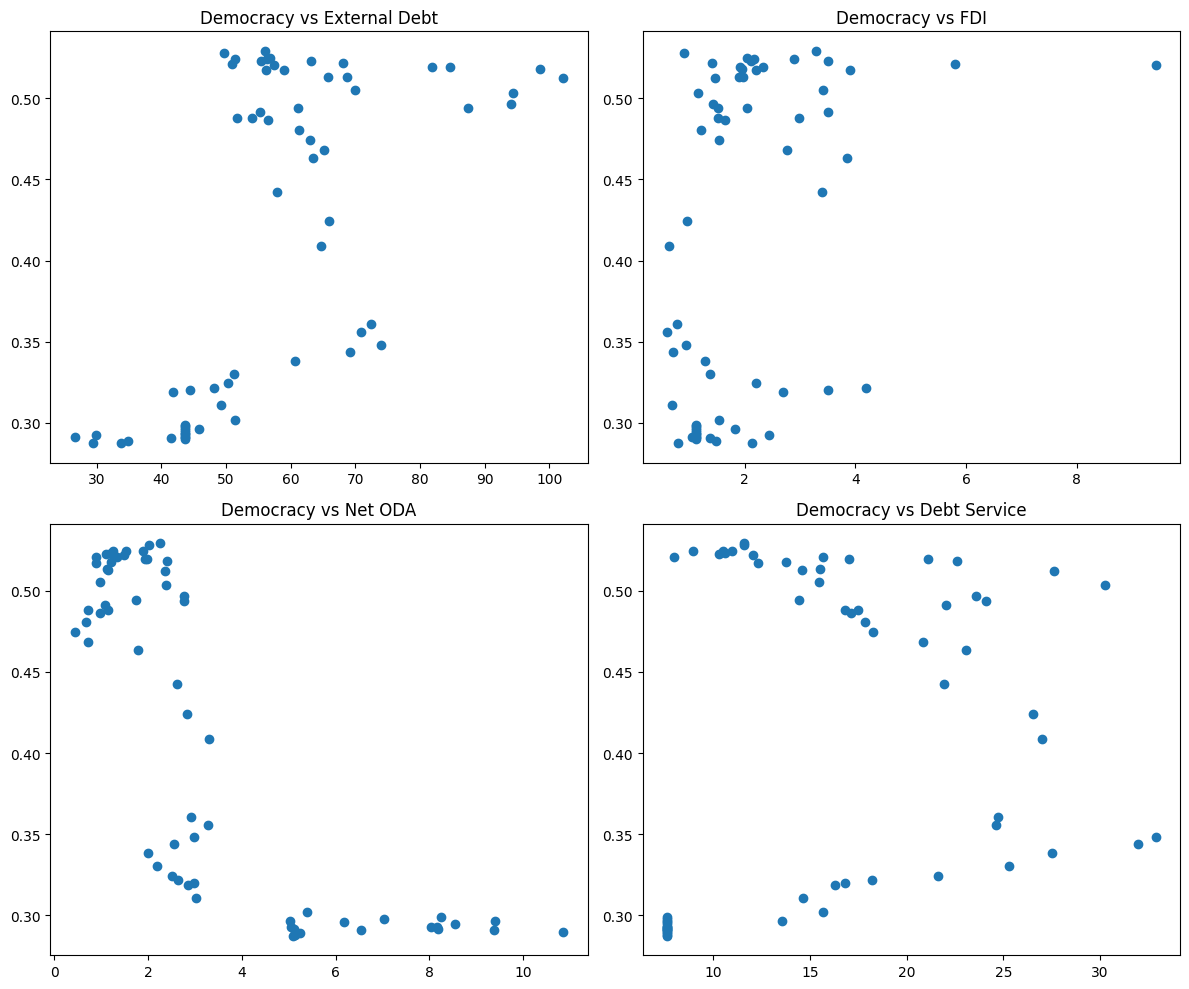

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12,10))

axes[0,0].scatter(df_yearly['External_Debt_GNI'], df_yearly['v2x_polyarchy'])
axes[0,0].set_title("Democracy vs External Debt")

axes[0,1].scatter(df_yearly['FDI_GDP'], df_yearly['v2x_polyarchy'])
axes[0,1].set_title("Democracy vs FDI")

axes[1,0].scatter(df_yearly['Net_ODA_GNI'], df_yearly['v2x_polyarchy'])
axes[1,0].set_title("Democracy vs Net ODA")

axes[1,1].scatter(df_yearly['Debt_Service_Exports'], df_yearly['v2x_polyarchy'])
axes[1,1].set_title("Democracy vs Debt Service")

plt.tight_layout()
plt.show()


Regression

In [ ]:
import statsmodels.api as sm

X = df_yearly[['External_Debt_GNI','FDI_GDP','Net_ODA_GNI','Debt_Service_Exports']]
y = df_yearly['v2x_polyarchy']

X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:          v2x_polyarchy   R-squared:                       0.873
Model:                            OLS   Adj. R-squared:                  0.865
Method:                 Least Squares   F-statistic:                     99.90
Date:                Fri, 29 Aug 2025   Prob (F-statistic):           2.55e-25
Time:                        20:44:35   Log-Likelihood:                 121.62
No. Observations:                  63   AIC:                            -233.2
Df Residuals:                      58   BIC:                            -222.5
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    0.3627 

| Variable          | Effect on Democracy (v2x\_polyarchy) | Simple explanation                                                  |
| ----------------- | ------------------------------------ | ------------------------------------------------------------------- |
| **Constant**      | 0.36                                 | If all factors were zero, democracy would be at 0.36.               |
| **External Debt** | +0.0043 per unit                     | More borrowing slightly increases democracy.                        |
| **FDI**           | +0.0070 per unit                     | More foreign investment slightly increases democracy (weak effect). |
| **Net ODA**       | -0.0256 per unit                     | More foreign aid decreases democracy.                               |
| **Debt Service**  | -0.0079 per unit                     | Higher debt payments decrease democracy.                            |


Foreign aid may reduce democracy because governments rely on it instead of building strong institutions.

Borrowing (external debt) might help democracy slightly, maybe because loans finance development or social programs.

Debt payments reduce democracy — too much debt burden weakens the government.

FDI helps a little, but not very strongly.

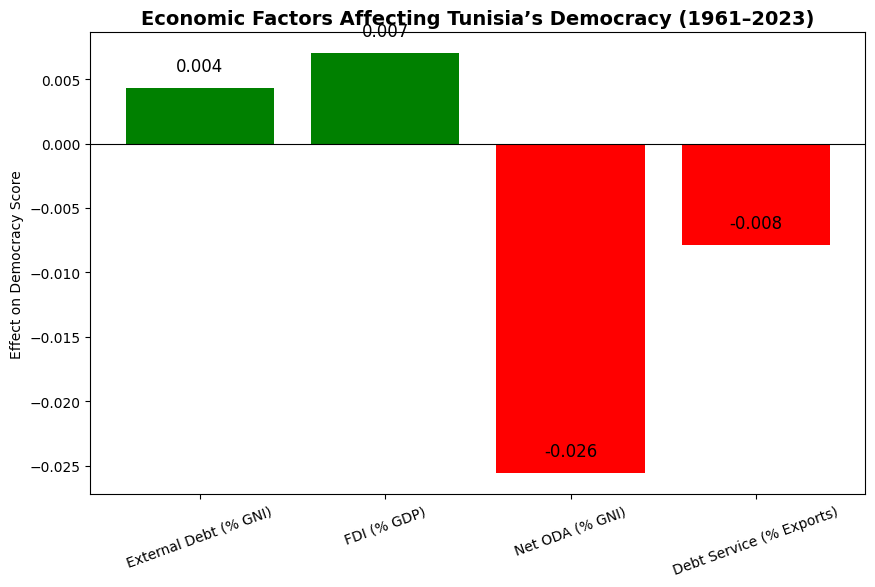

In [ ]:
import matplotlib.pyplot as plt

# Regression coefficients
effects = {
    'External Debt (% GNI)': 0.0043,
    'FDI (% GDP)': 0.0070,
    'Net ODA (% GNI)': -0.0256,
    'Debt Service (% Exports)': -0.0079
}

# Colors: green = helps democracy, red = hurts democracy
colors = ['green' if v > 0 else 'red' for v in effects.values()]

plt.figure(figsize=(10,6))
bars = plt.bar(effects.keys(), effects.values(), color=colors)

# Add value labels on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.001, f'{yval:.3f}', ha='center', va='bottom', fontsize=12)

plt.title('Economic Factors Affecting Tunisia’s Democracy (1961–2023)', fontsize=14, fontweight='bold')
plt.ylabel('Effect on Democracy Score')
plt.xticks(rotation=20)
plt.axhline(0, color='black', linewidth=0.8)
plt.show()


# Readme

In Tunisia (1961–2023), changes in external debt, debt service, and foreign aid were strongly associated with fluctuations in democracy. While higher external debt slightly supported democratic consolidation, heavy debt service and greater reliance on Net ODA constrained democratic institutions. FDI showed a modest positive effect. These patterns suggest that financial structures—particularly obligations to creditors and dependence on aid—play a critical role in shaping political outcomes, with economic expansion alone insufficient to guarantee democratic resilience.

# VAR / Granger / IRF / DiD Analysis

In [39]:
!pip install ruptures


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 27.3 MB/s eta 0:00:00


In [41]:
print(df_analysis.columns)


Index(['Year', 'External_Debt_GNI', 'FDI_GDP', 'Net_ODA_GNI',
       'Debt_Service_Exports'],
      dtype='object')


In [46]:
# 1️⃣ Filter Tunisia and select democracy score
tunisia = df_demo[df_demo["country_name"] == "Tunisia"].copy()

# Pick one democracy column (adjust if needed)
score_col = next((c for c in ["v2x_polyarchy", "v2x_regime", "v2x_para_dem", "v2x_lib_dem"] if c in tunisia.columns), None)
if score_col is None:
    numeric_cols = tunisia.select_dtypes(include=[float, int]).columns.tolist()
    raise ValueError(f"No democracy score column found. Available numeric cols: {numeric_cols}")

tunisia = tunisia[["year", score_col]].rename(columns={"year":"Year", score_col:"Democracy_Score"})
tunisia = tunisia.dropna(subset=["Democracy_Score"]).drop_duplicates(subset=["Year"])
tunisia["Year"] = tunisia["Year"].astype(int)
tunisia = tunisia.sort_values("Year").reset_index(drop=True)

# 2️⃣ Merge with economic indicators
tunisia_econ_demo = (
    tunisia
    .merge(gdp, on="Year", how="inner")
    .merge(inflation, on="Year", how="inner")
    .merge(youth_unemp, on="Year", how="inner")
)

print(tunisia_econ_demo.head())
print(tunisia_econ_demo.columns)



   Year  Democracy_Score       GDP_USD  Inflation  Youth_Unemployment
0  1991            0.198  1.307478e+10   8.193715              30.392
1  1992            0.197  1.549671e+10   5.824345              30.101
2  1993            0.194  1.460834e+10   3.974956              30.700
3  1994            0.189  1.563317e+10   4.733231              30.882
4  1995            0.188  1.803088e+10   6.244150              31.740
Index(['Year', 'Democracy_Score', 'GDP_USD', 'Inflation',
       'Youth_Unemployment'],
      dtype='object')



--- VAR Results for lag=1 ---
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sun, 31, Aug, 2025
Time:                     14:14:54
--------------------------------------------------------------------
No. of Equations:         4.00000    BIC:                    41.7874
Nobs:                     33.0000    HQIC:                   41.1856
Log likelihood:          -841.827    FPE:                5.73093e+17
AIC:                      40.8804    Det(Omega_mle):     3.25947e+17
--------------------------------------------------------------------
Results for equation Democracy_Score
                           coefficient       std. error           t-stat            prob
----------------------------------------------------------------------------------------
const                        -0.356667         0.172855           -2.063           0.039
L1.Democracy_Score            0.682818         0.108515            6.292    

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


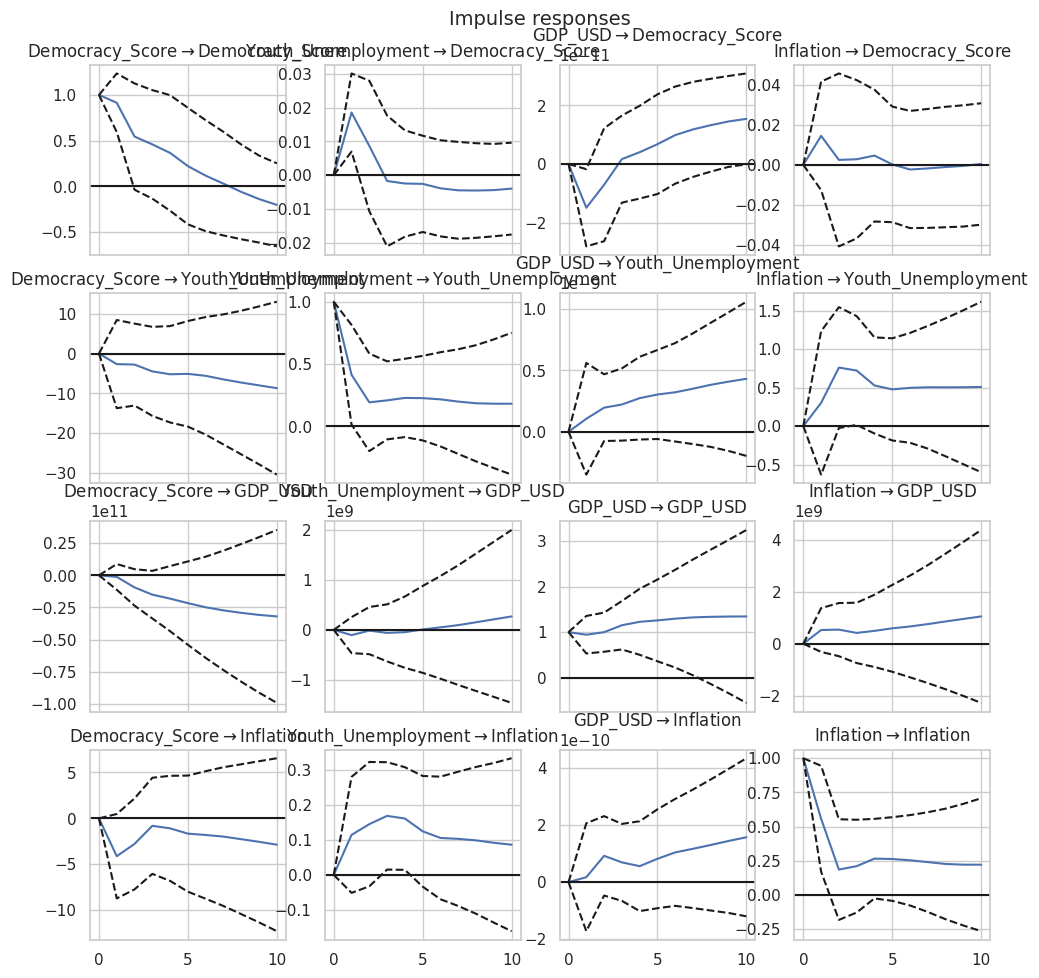

                            OLS Regression Results                            
Dep. Variable:        Democracy_Score   R-squared:                       0.795
Model:                            OLS   Adj. R-squared:                  0.788
Method:                 Least Squares   F-statistic:                     123.9
Date:                Sun, 31 Aug 2025   Prob (F-statistic):           1.55e-12
Time:                        14:14:56   Log-Likelihood:                 27.854
No. Observations:                  34   AIC:                            -51.71
Df Residuals:                      32   BIC:                            -48.65
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       0.0954      0.012      7.762      

In [47]:
# --- VAR / Granger / IRF / DiD Analysis ---

from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import grangercausalitytests
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

# Use your corrected dataframe
variables = ['Democracy_Score', 'Youth_Unemployment', 'GDP_USD', 'Inflation']

# --- VAR Model + Lag Robustness ---
var_model = VAR(tunisia_econ_demo[variables])

for lag in range(1, 4):
    result = var_model.fit(lag)
    print(f"\n--- VAR Results for lag={lag} ---")
    print(result.summary())
    print("AIC:", result.aic, "BIC:", result.bic)

# --- Granger Causality Tests ---
maxlag = 3
for col in ['Youth_Unemployment', 'GDP_USD', 'Inflation']:
    print(f"\nGranger causality: {col} -> Democracy_Score")
    grangercausalitytests(tunisia_econ_demo[['Democracy_Score', col]], maxlag=maxlag, verbose=True)

# --- Impulse Response Functions (IRFs) ---
best_lag = 2
var_result = var_model.fit(best_lag)
irf = var_result.irf(10)  # 10 periods
irf.plot(orth=False)
plt.show()

# --- Difference-in-Differences (DiD) / Event Study ---
tunisia_econ_demo['post_2011'] = (tunisia_econ_demo['Year'] >= 2011).astype(int)
tunisia_econ_demo['treated'] = 1  # Tunisia is treated
tunisia_econ_demo['interaction'] = tunisia_econ_demo['post_2011'] * tunisia_econ_demo['treated']

did_model = smf.ols('Democracy_Score ~ treated + post_2011 + interaction', data=tunisia_econ_demo).fit()
print(did_model.summary())



**1-  VAR Results (lags 1–3)**
VAR models how democracy, youth unemployment, GDP, and inflation interact over time.

Key observations:

- Democracy_Score equation:
- Past democracy matters a lot (L1.Democracy_Score has strong positive coefficients).
- Past youth unemployment also seems to increase democracy slightly at lag 1–3 (coeff ~0.01–0.02, significant).
- GDP and inflation effects are mostly weak or not significant.

Youth_Unemployment equation:

Its own past values strongly predict future unemployment (makes sense) Democracy has small/variable effects here.

GDP equation:

Past GDP strongly predicts future GDP. Democracy and unemployment effects are weak or mixed.

Inflation equation:

Past inflation predicts future inflation (expected).

Effects of democracy, unemployment, GDP mostly weak.

**Democracy is mostly influenced by its own past and youth unemployment, while economic indicators mostly follow their own dynamics.**

**2- Granger Causality : **

Tests whether past values of one variable help predict another.

Results for Democracy_Score:

Predictor	Significant?	Interpretation
Youth_Unemployment	Yes (p < 0.05 across lags 1–3)	Changes in youth unemployment help predict democracy.
GDP_USD	Mostly yes (p ~0.03–0.05)	GDP also has some predictive power on democracy.
Inflation	No (p > 0.5)	Inflation does not predict democracy.

**Youth unemployment is the strongest economic predictor of democracy in Tunisia. GDP helps a bit. Inflation doesn’t.**

**3- DiD (Difference-in-Differences) / Event Study:**

Examines the effect of the 2011 revolution on democracy.

Key numbers:

interaction = 0.2132, p < 0.001 → positive and significant.

This means democracy improved significantly after 2011.

The intercept and post_2011 terms also confirm a shift in democracy levels.

⚠️ Note:  warning about “strong multicollinearity or singular matrix” happens because you coded treated = 1 for all rows (only Tunisia). This doesn’t affect interpretation if you only look at interaction as the “event effect,” but normally DiD is better with treated vs control.

# Readme

Using VAR and Granger causality analysis, we find that Tunisia’s democracy is mainly influenced by its past levels and by youth unemployment. GDP has a minor effect, while inflation does not. Event-study (DiD) analysis shows that the 2011 revolution had a clear positive effect on democracy scores.